<a href="https://colab.research.google.com/github/PaiGV/Challenge-Alura-Challenge-Telecom-X-2/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE

In [6]:
# Enlace a CSV parte 1
url = 'https://raw.githubusercontent.com/PaiGV/Challenge-Alura-Challenge-Telecom-X-2/refs/heads/main/Telecom_X_.csv'
df_ml = pd.read_csv(url)

print("✔ Archivo enlazado")

✔ Archivo enlazado


In [4]:
# Lectura de tablas
display(df_ml.head())

print("\n--- Información ---")
df_ml.info()

print("\n--- Valores Nulos ---")
print(df_ml.isnull().sum())

,customerID,Abandono,Genero,AdultoMayor,Conyuge,Dependientes,MesesCliente,ServicioTelefono,LineasMultiples,TipoInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,TipoContrato,FacturaDigital,MetodoPago,CuotaMensual,GastoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Un año,Si,Cheque por correo,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mes a mes,No,Cheque por correo,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mes a mes,Si,Cheque electronico,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mes a mes,Si,Cheque electronico,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,Si,No,3,Si,No,Fibra optica,...,No,Si,Si,No,Mes a mes,Si,Cheque por correo,83.9,267.40,2.80



--- Información ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7032 non-null   object 
 1   Abandono               7032 non-null   float64
 2   Genero                 7032 non-null   object 
 3   AdultoMayor            7032 non-null   int64  
 4   Conyuge                7032 non-null   object 
 5   Dependientes           7032 non-null   object 
 6   MesesCliente           7032 non-null   int64  
 7   ServicioTelefono       7032 non-null   object 
 8   LineasMultiples        7032 non-null   object 
 9   TipoInternet           7032 non-null   object 
 10  SeguridadOnline        7032 non-null   object 
 11  RespaldoOnline         7032 non-null   object 
 12  ProteccionDispositivo  7032 non-null   object 
 13  SoporteTecnico         7032 non-null   object 
 14  StreamingTV            7032 non-nul

In [5]:
# Eliminación de Columnas Irrelevantes
columnas_a_borrar = ['customerID', 'GastoTotal', 'Cuentas_Diarias']

df_ml = df_ml.drop(columns=columnas_a_borrar)

print(f"✔ Se eliminaron {len(columnas_a_borrar)} columnas por redundancia y falta de valor predictivo.")
print(f"✔ Variables finales para el modelo: {list(df_ml.columns)}")

✔ Se eliminaron 3 columnas por redundancia y falta de valor predictivo.
✔ Variables finales para el modelo: ['Abandono', 'Genero', 'AdultoMayor', 'Conyuge', 'Dependientes', 'MesesCliente', 'ServicioTelefono', 'LineasMultiples', 'TipoInternet', 'SeguridadOnline', 'RespaldoOnline', 'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV', 'StreamingPeliculas', 'TipoContrato', 'FacturaDigital', 'MetodoPago', 'CuotaMensual']


In [7]:
# Encoding
columnas_binarias = ['Genero', 'Conyuge', 'Dependientes', 'ServicioTelefono', 'FacturaDigital']

for col in columnas_binarias:
    if 'Si' in df_ml[col].unique():
        df_ml[col] = df_ml[col].map({'Si': 1, 'No': 0})
    else:
        df_ml[col] = pd.factorize(df_ml[col])[0]


columnas_multi = ['LineasMultiples', 'TipoInternet', 'SeguridadOnline',
                  'RespaldoOnline', 'ProteccionDispositivo', 'SoporteTecnico',
                  'StreamingTV', 'StreamingPeliculas', 'TipoContrato', 'MetodoPago']

df_ml = pd.get_dummies(df_ml, columns=columnas_multi)


In [8]:
print("✔ Codificación finalizada.")
print(f"✔ Nuevas dimensiones: {df_ml.shape}")
df_ml.info()

✔ Codificación finalizada.
✔ Nuevas dimensiones: (7032, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customerID                         7032 non-null   object 
 1   Abandono                           7032 non-null   float64
 2   Genero                             7032 non-null   int64  
 3   AdultoMayor                        7032 non-null   int64  
 4   Conyuge                            7032 non-null   int64  
 5   Dependientes                       7032 non-null   int64  
 6   MesesCliente                       7032 non-null   int64  
 7   ServicioTelefono                   7032 non-null   int64  
 8   FacturaDigital                     7032 non-null   int64  
 9   CuotaMensual                       7032 non-null   float64
 10  GastoTotal                         7032 non-null   float64
 

✔ Análisis de Balanceo de Clases:
Clientes que se Quedan (0): 5163 (73.42%)
Clientes que se Van (1):    1869 (26.58%)


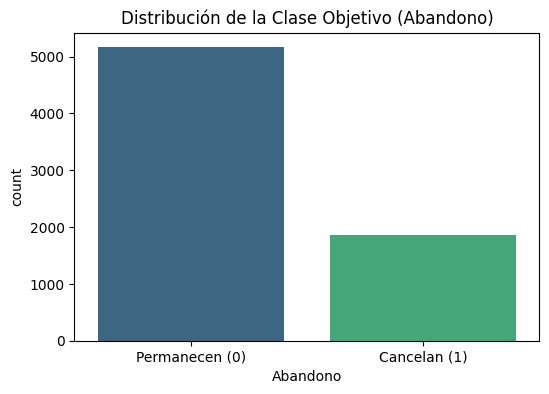

In [11]:
# Verificación de la Proporción de Cancelación (Churn)

conteo_abandono = df_ml['Abandono'].value_counts()

proporcion_abandono = df_ml['Abandono'].value_counts(normalize=True) * 100

print("✔ Análisis de Balanceo de Clases:")
print(f"Clientes que se Quedan (0): {conteo_abandono[0]} ({proporcion_abandono[0]:.2f}%)")
print(f"Clientes que se Van (1):    {conteo_abandono[1]} ({proporcion_abandono[1]:.2f}%)")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Abandono', data=df_ml, palette='viridis')
plt.title('Distribución de la Clase Objetivo (Abandono)')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()